In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from scipy.stats import ttest_ind, f_oneway
from sklearn.metrics import r2_score
import statsmodels.api as sm
from statsmodels.formula.api import ols
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import make_pipeline

In [2]:
data = pd.read_csv('dataset.csv')

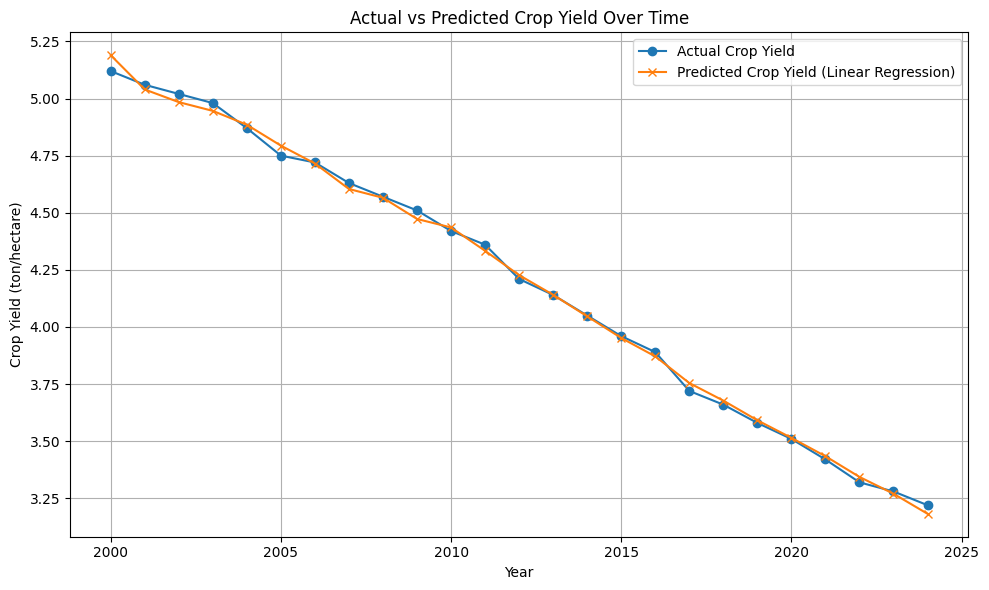

In [3]:
features = ['Average_Temperature_C', 'Annual_Rainfall_mm', 'Extreme_Weather_Events', 'Soil_Moisture_Percentage']
X = data[features]
y = data['Crop_Yield_ton_per_hectare']

# Create and train the linear regression model
model = LinearRegression()
model.fit(X, y)

# Predict crop yield using the trained model
data['Predicted_Crop_Yield'] = model.predict(X)

# Plot actual vs predicted crop yield over time
plt.figure(figsize=(10, 6))
plt.plot(data['Year'], y, label='Actual Crop Yield', marker='o')
plt.plot(data['Year'], data['Predicted_Crop_Yield'], label='Predicted Crop Yield (Linear Regression)', marker='x')
plt.xlabel('Year')
plt.ylabel('Crop Yield (ton/hectare)')
plt.title('Actual vs Predicted Crop Yield Over Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

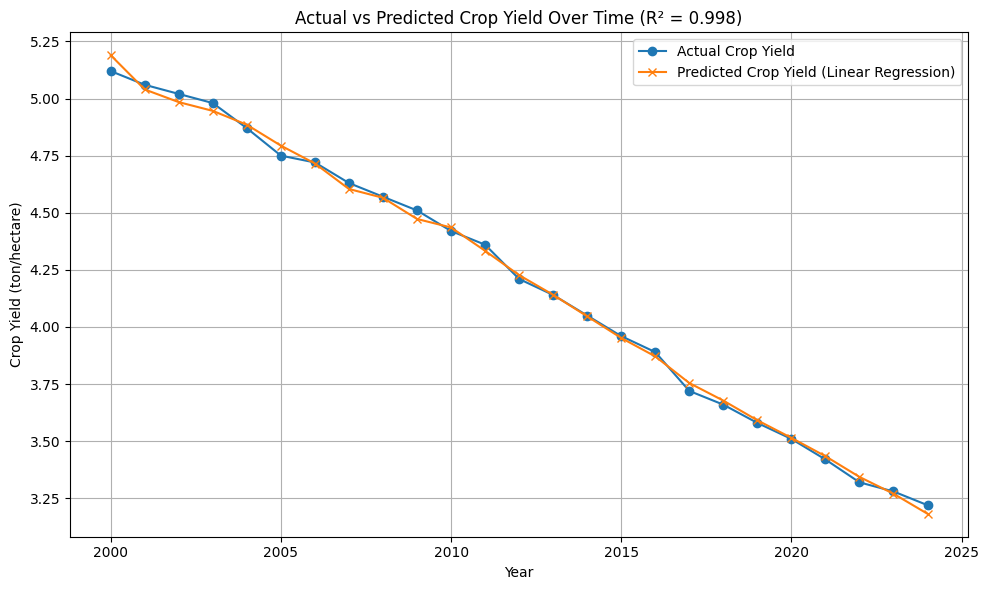

(0.9980788464744762,
 <class 'statsmodels.iolib.summary.Summary'>
 """
                                 OLS Regression Results                                
 Dep. Variable:     Crop_Yield_ton_per_hectare   R-squared:                       0.998
 Model:                                    OLS   Adj. R-squared:                  0.998
 Method:                         Least Squares   F-statistic:                     2598.
 Date:                        Wed, 16 Apr 2025   Prob (F-statistic):           7.52e-27
 Time:                                00:08:17   Log-Likelihood:                 55.300
 No. Observations:                          25   AIC:                            -100.6
 Df Residuals:                              20   BIC:                            -94.51
 Df Model:                                   4                                         
 Covariance Type:                    nonrobust                                         
                                coef    std err  

In [4]:
r2 = r2_score(y, data['Predicted_Crop_Yield'])

# Generate linear regression summary using statsmodels
X_sm = sm.add_constant(X)  # Add constant term for intercept
model_sm = sm.OLS(y, X_sm).fit()
summary = model_sm.summary()

# Plotting again for completeness
plt.figure(figsize=(10, 6))
plt.plot(data['Year'], y, label='Actual Crop Yield', marker='o')
plt.plot(data['Year'], data['Predicted_Crop_Yield'], label='Predicted Crop Yield (Linear Regression)', marker='x')
plt.xlabel('Year')
plt.ylabel('Crop Yield (ton/hectare)')
plt.title(f'Actual vs Predicted Crop Yield Over Time (R² = {r2:.3f})')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

r2, summary

In [5]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

# Fit models and collect coefficients or feature importances
results = {}
for name, model in models.items():
    if name in ["Ridge Regression", "Lasso Regression", "Linear Regression"]:
        pipeline = make_pipeline(StandardScaler(), model)
        pipeline.fit(X, y)
        if hasattr(model, 'coef_'):
            results[name] = pipeline.named_steps[model.__class__.__name__.lower()].coef_
    else:
        model.fit(X, y)
        results[name] = model.feature_importances_

# Combine results into a DataFrame
influence_df = pd.DataFrame(results, index=features)

influence_df

,Linear Regression,Ridge Regression,Lasso Regression,Random Forest
Average_Temperature_C,-0.627984,-0.279027,-0.503317,0.379392
Annual_Rainfall_mm,-0.292991,0.064854,0.000000,0.283481
Extreme_Weather_Events,-0.014206,-0.096945,-0.000000,0.130942
Soil_Moisture_Percentage,0.252126,0.154990,0.000000,0.206185
